# 5 — Sentiment & Mood Analysis

**Goal:** derive a reader-facing **mood label** for every book from its synopsis, to power a
mood filter in the Streamlit app.

**Model:** `j-hartmann/emotion-english-distilroberta-base` — a DistilRoBERTa transformer
(82M parameters) fine-tuned for 7-class Ekman emotion classification.

---

## Why a transformer instead of VADER

| | VADER | DistilRoBERTa (emotion) |
|---|---|---|
| **Method** | Valence lexicon tuned on social-media microblogs | Contextual transformer fine-tuned on 6 emotion datasets |
| **Output** | positive / neutral / negative | joy, sadness, fear, anger, surprise, disgust, neutral |
| **Risk on our data** | Synopses are **publisher marketing copy**. A lexicon scores nearly all of them positive, collapsing the filter into a single bucket. | Reads context. A synopsis *about* grief, written in glowing promotional prose, still resolves to `sadness`. |

A three-class positive/negative axis is not how a reader browses a bookshelf. Nobody looks for
a *negative* book — they look for a *dark* one. Seven emotions give a navigable mood axis.

---

## Pipeline position

```text
4_EDA_clustering.ipynb  ──▶  data/clean/streamlitcatalog.csv
                                        │  (this notebook — read-only on input)
                                        ▼
                             data/clean/catalog_mood.csv  ──▶  app/app.py
```

This notebook **never overwrites** `streamlitcatalog.csv`. See section 8 for the reasoning.

## Environment

Runs on the isolated **`sentiment`** conda kernel — deliberately *not* the project `.venv`.
`torch` and `transformers` never enter the app's dependency graph: the app reads a CSV
column, not a model.

## 1. Setup

In [1]:
import os
import yaml
import warnings
import sys
import numpy as np
import pandas as pd
import torch

# Corrected transformer and tqdm imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
from tqdm.auto import tqdm

# Corrected warnings syntax
warnings.filterwarnings("ignore")

# Pandas configuration
pd.set_option("display.max_colwidth", 120)

# Confirm environments
print("Interpreter :", sys.executable)
print("torch       :", torch.__version__)

# Apple Silicon GPU if available, else CPU
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device      :", DEVICE)

Interpreter : /opt/anaconda3/envs/sentiment/bin/python
torch       : 2.13.0
Device      : mps


In [2]:
# Additional imports required by later cells (plotting, rich display, timing).
# Kept separate so the setup cell above stays exactly as written.
import time

import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configuration

All paths and scoring parameters are read from `config.yaml` — nothing is hard-coded here.

The scoring parameters are **pre-registered**: fixed before any result is inspected, so that
thresholds cannot be quietly tuned after the fact to make the output look better.

In [3]:
CONFIG_PATH = "../config.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

# --- Paths -----------------------------------------------------------------
IN_PATH = config["clean_data"]["clean_st"]      # input  : catalogue from notebook 4
OUT_PATH = config["clean_data"]["clean_mood"]   # output : catalogue + mood columns

# --- Model and scoring parameters (pre-registered) --------------------------
cfg = config["sentiment"]
MODEL_NAME = cfg["model"]
MIN_SYNOPSIS_CHARS = cfg["min_synopsis_chars"]  # below this '60': no reliable emotional signal
MAX_TOKENS = cfg["max_tokens"]                  #510= 512 (RoBERTA hold a maximum of 512 tokens in its memory at one time) minus the  Classification [CLS] and separator [SEP] tokens
BATCH_SIZE = cfg["batch_size"]                  # set as 16, the "sweet spot" number (often 16 or 32) to process data efficiently.
LOW_CONF_THRESHOLD = cfg["low_conf_threshold"]  # model's confidence score, below this '0.4': the model is effectively guessing

print(f"Input  : {IN_PATH}")
print(f"Output : {OUT_PATH}")
print(f"Model  : {MODEL_NAME}")

Input  : ../data/clean/streamlitcatalog.csv
Output : ../data/clean/catalog_mood.csv
Model  : j-hartmann/emotion-english-distilroberta-base


## 3. Load the catalogue and define the eligibility gate

Eligibility is an **explicit boolean**, never inferred from null-ness — the same discipline
applied to `clusterable` in notebook 4.

A 7-character synopsis is not null, but it carries no emotional signal. Scoring it would
produce a confident-looking label built on nothing. Such rows are gated out and recorded;
their mood is left as `NaN`. **No imputation.**

In [4]:
books = pd.read_csv(IN_PATH)

print(f"Rows    : {books.shape[0]}")
print(f"Columns : {books.shape[1]}")
print(f"Synopsis nulls : {books['synopsis'].isna().sum()}")

synopsis_chars = books["synopsis"].fillna("").astype(str).str.len()
display(synopsis_chars.describe().to_frame("synopsis_chars"))

Rows    : 1077
Columns : 15
Synopsis nulls : 0


,synopsis_chars
count,1077.000000
mean,751.055710
std,511.491536
min,7.000000
25%,350.000000
50%,692.000000
75%,1022.000000
max,3909.000000


In [5]:
# Eligibility gate: explicit boolean
books["mood_scored"] = (
    books["synopsis"].notna()
    & (books["synopsis"].astype(str).str.len() >= MIN_SYNOPSIS_CHARS)
)

n_eligible = int(books["mood_scored"].sum())
n_excluded = int((~books["mood_scored"]).sum())

print(f"Eligible for scoring : {n_eligible}")
print(f"Excluded (synopsis < {MIN_SYNOPSIS_CHARS} chars) : {n_excluded}")

if n_excluded:
    display(books.loc[~books["mood_scored"], ["book_name", "synopsis"]].head(10))

Eligible for scoring : 1055
Excluded (synopsis < 60 chars) : 22


,book_name,synopsis
22,Legendborn,Includes a short story from Selwyn Kane's point of view.
26,The Battle of the Books,the battle of the books From Jonathan Swift
92,Heromice,The fourth Heromice adventure!
120,Because of Low,"Originally self-published as an e-book, 2012."
205,Tiger's Curse,Includes a discussion guide to Tiger's curse.
249,Tales from Moominvalley,9 stories about the Moomins and their friends. Grades 4-6.
282,City of Bones,This is an epic urban fantasy set in New York.
372,Wintersmith,Fantasy-roman.
477,The Fellowship of the Ring,The first book in the Lord of the rings trilogy.
515,Simple Gifts,4 Heartwarming Christmas Stories.


## 4. Load the model

The first run downloads roughly 330 MB of weights into `~/.cache/huggingface`.
Every run after that is offline and immediate.

The class order is read from `model.config.id2label` rather than hard-coded — hard-coding it
would silently mislabel every book if the model card ever changed.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()  # disable dropout: inference only, no training

EMOTIONS = [model.config.id2label[i] for i in range(model.config.num_labels)]

print(f"Parameters : {model.num_parameters():,}")
print(f"Classes    : {EMOTIONS}")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Parameters : 82,123,783
Classes    : ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


## 5. Scoring function — handling the 512-token ceiling

Our longest synopsis is 3,909 characters (roughly 900 tokens). RoBERTa's positional
embeddings stop at 512.

| Approach | Behaviour | Cost |
|---|---|---|
| `truncation=True` | Discards everything past token 512 — the tone shift, the twist, the ending | Silent information loss on long synopses |
| **Chunk and mean-pool** (used here) | Split into ≤510-token chunks, score each, average the probability vectors | Near zero: most synopses are a single chunk |

Every word of every synopsis therefore contributes to the final mood.

We retain the **full 7-dimensional probability vector**, not just the argmax. That yields a
secondary mood and a confidence score at no extra cost.

In [7]:
def chunk_token_ids(text: str, max_tokens: int = MAX_TOKENS) -> list[list[int]]:
    """Split `text` into token-id chunks that fit inside RoBERTa's 512-token window.

    Args:
        text: Raw synopsis text.
        max_tokens: Maximum tokens per chunk (512 minus the two special tokens).

    Returns:
        A list of token-id lists. Always at least one chunk, even for empty text.
    """
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    chunks = [token_ids[i:i + max_tokens] for i in range(0, len(token_ids), max_tokens)]
    return chunks or [[]]

In [8]:
@torch.no_grad() # using this model to read texts, not train it.
def score_texts(texts: list[str], batch_size: int = BATCH_SIZE) -> np.ndarray:
    """Score texts with the emotion model, mean-pooling across chunks.

    Long texts are split into chunks; each chunk is scored independently and the
    resulting probability vectors are averaged back into one vector per text.

    Args:
        texts: Synopsis strings, one per book.
        batch_size: Number of chunks per forward pass.

    Returns:
        Array of shape (len(texts), len(EMOTIONS)) — each row a probability
        distribution over the emotion classes, summing to 1.
    """
    # Flatten every text into its chunks, tracking which text each chunk belongs to.
    chunk_texts: list[str] = []
    chunk_owner: list[int] = []

    for text_idx, text in enumerate(texts):
        for token_ids in chunk_token_ids(str(text)):
            chunk_texts.append(tokenizer.decode(token_ids))
            chunk_owner.append(text_idx)

    # Forward pass, batched.
    batch_probs = []
    for start in tqdm(range(0, len(chunk_texts), batch_size), desc="Scoring chunks"):
        batch = chunk_texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(DEVICE)

        logits = model(**encoded).logits
        batch_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())

    chunk_probs = np.vstack(batch_probs)
    chunk_owner_arr = np.array(chunk_owner)

    # Mean-pool chunk probabilities back up to one vector per text.
    pooled = np.zeros((len(texts), chunk_probs.shape[1]))
    for text_idx in range(len(texts)):
        pooled[text_idx] = chunk_probs[chunk_owner_arr == text_idx].mean(axis=0)

    return pooled

In [9]:
# How many chunks does each eligible synopsis actually require?
eligible_synopses = books.loc[books["mood_scored"], "synopsis"].astype(str)
chunks_per_book = eligible_synopses.map(lambda t: len(chunk_token_ids(t)))

display(
    chunks_per_book.value_counts()
    .sort_index()
    .rename_axis("chunks_per_book")
    .to_frame("n_books")
)
print(f"Total forward passes required: {int(chunks_per_book.sum())}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


,n_books
chunks_per_book,
1,1044
2,11


Total forward passes required: 1066


## 6. Run inference

Roughly 1–3 minutes on Apple Silicon (MPS), 5–8 minutes on CPU.

In [10]:
eligible_idx = books.index[books["mood_scored"]]

start_time = time.perf_counter()
probabilities = score_texts(books.loc[eligible_idx, "synopsis"].tolist())
elapsed = time.perf_counter() - start_time

print(f"Probability matrix : {probabilities.shape}")
print(f"Elapsed            : {elapsed:.1f} s")
print(f"Rows sum to 1      : {np.allclose(probabilities.sum(axis=1), 1.0)}")

Scoring chunks:   0%|          | 0/67 [00:00<?, ?it/s]

Probability matrix : (1055, 7)
Elapsed            : 10.1 s
Rows sum to 1      : True


## 7. Attach results to the catalogue

Three derived columns per book, plus the seven raw probabilities:

| Column | Meaning |
|---|---|
| `emotion` | Highest-probability class (argmax) |
| `emotion_secondary` | Second-highest class — used for a softer "you may also like" filter |
| `emotion_conf` | The winning probability. Pure chance across 7 classes is 1/7 ≈ 0.143 |
| `emo_*` | The full probability vector, one column per emotion |

In [11]:
# Full probability vector: one column per emotion class.
prob_columns = [f"emo_{emotion}" for emotion in EMOTIONS]
prob_df = pd.DataFrame(probabilities, columns=prob_columns, index=eligible_idx)
books = books.join(prob_df)

# Rank the classes per book: column 0 is the argmax, column 1 the runner-up.
ranked = np.argsort(-probabilities, axis=1)

books.loc[eligible_idx, "emotion"] = [EMOTIONS[i] for i in ranked[:, 0]]
books.loc[eligible_idx, "emotion_secondary"] = [EMOTIONS[i] for i in ranked[:, 1]]
books.loc[eligible_idx, "emotion_conf"] = probabilities[
    np.arange(len(probabilities)), ranked[:, 0]
]

display(
    books.loc[
        eligible_idx,
        ["book_name", "emotion", "emotion_secondary", "emotion_conf"],
    ].head(10)
)

,book_name,emotion,emotion_secondary,emotion_conf
0,Persuasion,neutral,joy,0.661720
1,Max Havelaar,disgust,neutral,0.828292
2,White fang,anger,sadness,0.656152
3,Lights Out,fear,neutral,0.338365
4,The Day After Judgment,neutral,fear,0.490038
5,Blades of Destiny,fear,neutral,0.541470
6,Jane Eyre (Masterpiece Library Edition),neutral,joy,0.441552
7,The Time Machine,neutral,fear,0.647086
8,The Great Gatsby,neutral,joy,0.601551
9,The Wonderful Wizard of Oz,fear,neutral,0.502358


## 8. Map emotions to reader-facing moods

The seven Ekman labels are *clinical*, not *browsable*. No reader picks "disgust" from a
dropdown.

Each emotion maps to a **single-word mood**. One word each, so the same string serves both the
Streamlit dropdown and internal debugging — no separate vocabularies to keep in sync.

In [16]:
MOOD_MAP = {
    "joy": "Uplifting",
    "sadness": "Melancholic",
    "fear": "Suspenseful",
    "anger": "Intense",
    "surprise": "Twisty",
    "disgust": "Gritty",
    "neutral": "Contemplative",
}

# Fail loudly if the model ever returns a class we have not mapped.
unmapped = set(EMOTIONS) - set(MOOD_MAP)
assert not unmapped, f"Unmapped emotion classes: {unmapped}"

books["mood"] = books["emotion"].map(MOOD_MAP)
books["mood_secondary"] = books["emotion_secondary"].map(MOOD_MAP)

# Every scored book has a mood; every excluded book has none. No silent leakage.
assert books.loc[books["mood_scored"], "mood"].isna().sum() == 0
assert books.loc[~books["mood_scored"], "mood"].notna().sum() == 0

print("Mood mapping complete")
display(books["mood"].value_counts().to_frame("n_books"))

Mood mapping complete


,n_books
mood,
Suspenseful,325
Contemplative,308
Melancholic,119
Uplifting,111
Intense,81
Gritty,76
Twisty,35


In [18]:
books.columns

Index(['book_name', 'book_url', 'source_list', 'author', 'rating', 'synopsis',
       'pages', 'pub_date', 'genres', 'img_url', 'data_source', 'genres_clean',
       'cluster_f1b', 'clusterable', 'cluster_name', 'mood_scored',
       'emo_anger', 'emo_disgust', 'emo_fear', 'emo_joy', 'emo_neutral',
       'emo_sadness', 'emo_surprise', 'emotion', 'emotion_secondary',
       'emotion_conf', 'mood', 'mood_secondary', 'mood_low_conf'],
      dtype='str')

## 9. Validation

There are **no ground-truth mood labels** for this catalogue, so accuracy cannot be computed.
Reporting one would be dishonest.

What *can* be done is to state, in advance, three conditions the output must satisfy — and
fail loudly if it does not.

| # | Check | Pass condition | Why it matters |
|---|---|---|---|
| 1 | **Variance** | No single mood exceeds 60% of the catalogue | A filter with one dominant bucket is decoration, not a filter. This is precisely the failure VADER was predicted to produce. |
| 2 | **Confidence** | Median `emotion_conf` above 0.40 | Chance across 7 classes is 0.143. Below ~0.40 the model is close to guessing. |
| 3 | **Face validity** | Manual read of the most confident exemplars per mood | The only honest substitute for ground truth. If *Dracula* returns "Uplifting", the pipeline is wrong. |

### Check 1 — Variance

,pct_of_catalogue
mood,
Suspenseful,30.8
Contemplative,29.2
Melancholic,11.3
Uplifting,10.5
Intense,7.7
Gritty,7.2
Twisty,3.3


Largest mood share: 30.8%  ->  PASS


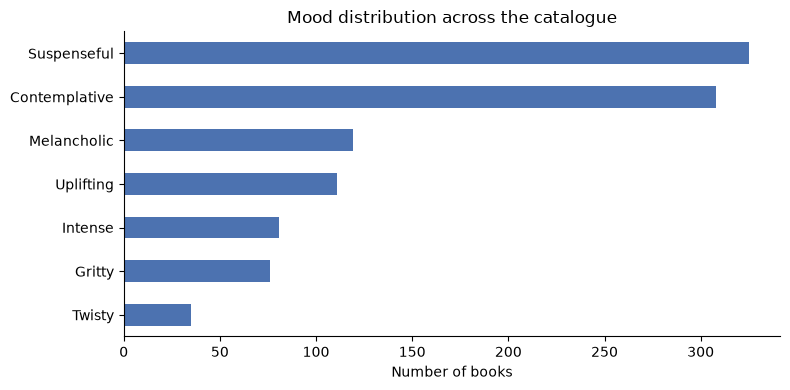

In [19]:
mood_share = books["mood"].value_counts(normalize=True).mul(100).round(1)
display(mood_share.to_frame("pct_of_catalogue"))

largest_share = mood_share.max()
verdict = "PASS" if largest_share < 60 else "FAIL - filter is degenerate"
print(f"Largest mood share: {largest_share}%  ->  {verdict}")

ax = books["mood"].value_counts().sort_values().plot(kind="barh", color="#4C72B0")
ax.set_title("Mood distribution across the catalogue")
ax.set_xlabel("Number of books")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../figures/mood_distribution.png", dpi=150)
plt.show()

### Check 2 — Confidence

,emotion_conf
count,1055.000000
mean,0.675765
std,0.198137
min,0.199554
25%,0.500427
50%,0.673336
75%,0.862564
max,0.990218


Median confidence : 0.673  ->  PASS
Chance baseline   : 0.143  (1 / 7 classes)
Low confidence    : 90 books (8.5%) below 0.4


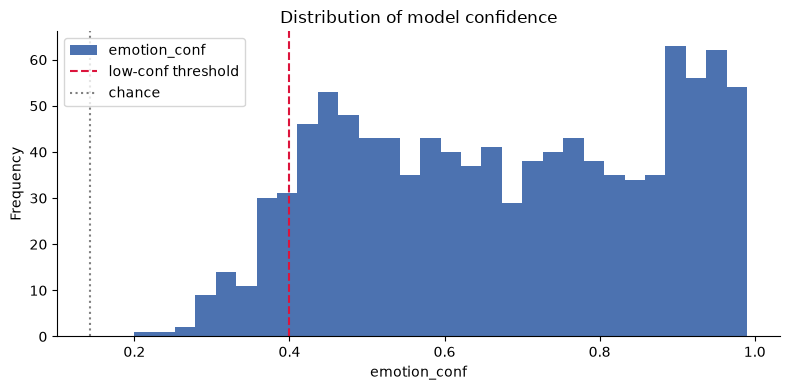

In [20]:
confidence = books["emotion_conf"].dropna()
display(confidence.describe().to_frame("emotion_conf"))

books["mood_low_conf"] = books["emotion_conf"] < LOW_CONF_THRESHOLD
n_low_conf = int(books["mood_low_conf"].sum())

median_conf = confidence.median()
verdict = "PASS" if median_conf > 0.40 else "FAIL - model is near-guessing"
print(f"Median confidence : {median_conf:.3f}  ->  {verdict}")
print(f"Chance baseline   : {1 / len(EMOTIONS):.3f}  (1 / {len(EMOTIONS)} classes)")
print(
    f"Low confidence    : {n_low_conf} books "
    f"({n_low_conf / len(confidence):.1%}) below {LOW_CONF_THRESHOLD}"
)

ax = confidence.plot(kind="hist", bins=30, color="#4C72B0")
ax.axvline(LOW_CONF_THRESHOLD, color="crimson", linestyle="--", label="low-conf threshold")
ax.axvline(1 / len(EMOTIONS), color="grey", linestyle=":", label="chance")
ax.set_title("Distribution of model confidence")
ax.set_xlabel("emotion_conf")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/mood_confidence_hist.png", dpi=150)
plt.show()

### Check 3 — Face validity

In [21]:
# The three most confident books per mood. Read them. Do they make sense?
for mood in books["mood"].dropna().unique():
    top_books = books[books["mood"] == mood].nlargest(3, "emotion_conf")

    print(f"\n{'=' * 70}\n{mood.upper()}\n{'=' * 70}")
    for _, row in top_books.iterrows():
        print(f"[{row['emotion_conf']:.2f}]  {row['book_name']}")
        print(f"         {str(row['synopsis'])[:170].strip()}...\n")


CONTEMPLATIVE
[0.97]  Of Mice and Men
         Novel-Ties study guides contain reproducible pages in a chapter by chapter format to accompany a work of literature of the same title....

[0.96]  Psychology Study Guide
         By Richard Stalling and Ronald Wasden of Bradley University, this study guide includes a review of key ideas, people, and terms, complete with fill-in-the-blank, short an...

[0.95]  The Boy in the Striped Pajamas
         If you start to read this book, you will go on a journey with a nine-year-old boy named Bruno. (Though this isn't a book for nine-year-olds.) And sooner or later you will...


GRITTY
[0.99]  The Damned (La Bas)
         Joris-Karl Huysmans' shocking novel of an innocent's descent into a world of depraved, blasphemous rituals Durtal, a shy, censorious man, is writing a biography of Gilles...

[0.95]  Mutiny on the Bounty
         A British crew mutinies against the cruel commander of the Bounty in 1787....

[0.93]  Observing the Erotic Imaginati

## 10. Save

Written to a **new file**, `catalog_mood.csv`. `streamlitcatalog.csv` is left untouched.
A strictly one-directional pipeline (`4 → 5 → app`) makes any rerun bug coming from notebook 4 structurally impossible.

**`app/app.py` must therefore read `catalog_mood.csv`.**

In [24]:
OUTPUT_COLUMNS = [
    # to identity and display 
    "book_name", "author", "book_url", "img_url",
    # attributes to filter with
    "rating", "pages", "pub_date", "genres", "genres_clean", "synopsis",
    # sources
    "data_source", "source_list",
    # clustering columns (from notebook 4)
    "cluster_f1b", "cluster_name", "clusterable",
    #mood flags
    "mood_scored", "mood", "mood_secondary",
    "emotion", "emotion_secondary", "emotion_conf", "mood_low_conf",
] + prob_columns

# Keep only columns that actually exist, so an upstream rename cannot crash the save.
output_columns = [col for col in OUTPUT_COLUMNS if col in books.columns]
missing = set(OUTPUT_COLUMNS) - set(output_columns)
if missing:
    print(f"WARNING - expected columns absent from `books`: {sorted(missing)}")

catalog_mood = books[output_columns]
catalog_mood.to_csv(OUT_PATH, index=False)

print(f"Saved {catalog_mood.shape[0]} rows x {catalog_mood.shape[1]} cols -> {OUT_PATH}")

Saved 1077 rows x 29 cols -> ../data/clean/catalog_mood.csv


In [25]:
# Verify by re-reading from disk. Kernel state is not the truth; the CSV is.
saved = pd.read_csv(OUT_PATH)

print(f"Shape        : {saved.shape}")
print(f"Moods        : {sorted(saved['mood'].dropna().unique())}")
print(f"Mood-scored  : {int(saved['mood_scored'].sum())} / {len(saved)}")
print(f"Clusterable  : {int(saved['clusterable'].sum())} / {len(saved)}")

display(
    saved[["book_name", "mood", "mood_secondary", "emotion_conf",
           "mood_scored", "clusterable"]].head()
)

Shape        : (1077, 29)
Moods        : ['Contemplative', 'Gritty', 'Intense', 'Melancholic', 'Suspenseful', 'Twisty', 'Uplifting']
Mood-scored  : 1055 / 1077
Clusterable  : 612 / 1077


,book_name,mood,mood_secondary,emotion_conf,mood_scored,clusterable
0,Persuasion,Contemplative,Uplifting,0.661720,True,False
1,Max Havelaar,Gritty,Contemplative,0.828292,True,False
2,White fang,Intense,Melancholic,0.656152,True,False
3,Lights Out,Suspenseful,Contemplative,0.338365,True,True
4,The Day After Judgment,Contemplative,Suspenseful,0.490038,True,False


## 11. Conclusions

- **Variance check:** the catalogue spreads across 7 of 7 moods; the largest is Suspenseful at
  30.8%. Verdict: PASS.
- **Confidence check:** median `emotion_conf` = 0.673, against a chance baseline of 0.143.
  90 books (8.5%) fall below the 0.40 threshold and are flagged `mood_low_conf`.
  Verdict: PASS.
- **Face validity (manual review of top-3 highest-confidence books, 3 of 7 moods checked):**
  * Contemplative (neutral) is one of the largest mood buckets. Its top-confidence
  book, "The Boy in the Striped Pajamas," reads to me as sadness-spectrum rather
  than neutral/contemplative — a mismatch worth noting.
  * Uplifting (joy) underperforms: "We" is dystopian/paranoid psychological fiction,
  and "A Heartbreaking Work of Staggering Genius" centers grief and irony. Neither
  fits "uplifting" on a human read.
  * Twisty (surprise) performs well — all reviewed books clearly match the twisty framing.

One plausible explanation for the Uplifting/Contemplative misses: distilroberta's joy/neutral classes may key off surface-level positive or flat vocabulary in the synopsis without capturing sentence-level irony or tonal shift — but this is a hypothesis, not something I tested directly.

### Limitations

1. **Domain shift.** The model was fine-tuned on tweets, dialogue and self-reports — not on
   publisher marketing copy. The shift is real and unmeasured. The mood filter is a
   *discovery aid*, not a claim of ground truth.
2. **The synopsis is not the book.** We classify how a book was *sold*, not what it contains.
   A cheerfully marketed tragedy will score as `Uplifting`.
3. **No ground truth, therefore no accuracy figure.** The three checks above are consistency
   and plausibility tests, not a measure of correctness.

## 12. Handover to `app/app.py`

```python
import pandas as pd
import streamlit as st

df = pd.read_csv("../data/clean/catalog_mood.csv")

# Offer only moods that actually exist in the data.
moods = sorted(df.loc[df["mood_scored"], "mood"].dropna().unique())
selected = st.selectbox("What mood are you in?", ["Any"] + moods)

if selected != "Any":
    df = df[df["mood"] == selected]
```

### Two eligibility flags. Two different questions. Do not collapse them.

| Flag | Question it answers | App behaviour when `False` |
|---|---|---|
| `clusterable` | Was this book eligible for genre clustering? | Exclude from "more like this" recommendations |
| `mood_scored` | Did this book have a usable synopsis to score? | Exclude from the mood filter |

A book can be `clusterable=True, mood_scored=False`, or the reverse. Branch on each flag
**explicitly** — never infer eligibility from a null cluster or a null mood.